# Pre-FoG Detection Model - Training and Testing
## Detect FoG events 2-5 seconds before they occur

This notebook implements a 3-class classifier:
- **Class 0**: Normal movement (no FoG)
- **Class 1**: Pre-FoG (2-5 seconds before FoG)
- **Class 2**: FoG (actual FoG event)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✓ Imports complete")

Device: cpu
✓ Imports complete


In [20]:
# ============================================================================
# LOAD DATA FROM SENSOR DATA
# ============================================================================

# Load sensor data
df_complete = pd.read_csv('sensor_data_complete.csv')
print(f"Loaded data shape: {df_complete.shape}")
print(f"Columns: {df_complete.columns.tolist()[:15]}...")

# Extract quaternion data
quat_cols = [col for col in df_complete.columns if 'q' in col.lower()]
print(f"\nQuaternion columns found: {len(quat_cols)}")
print(f"Sample columns: {quat_cols[:4]}")

Loaded data shape: (329027, 43)
Columns: ['timestamp', 'ankleL_acc_x', 'ankleL_acc_y', 'ankleL_acc_z', 'ankleL_gyro_x', 'ankleL_gyro_y', 'ankleL_gyro_z', 'ankleR_acc_x', 'ankleR_acc_y', 'ankleR_acc_z', 'ankleR_gyro_x', 'ankleR_gyro_y', 'ankleR_gyro_z', 'back_acc_x', 'back_acc_y']...

Quaternion columns found: 12
Sample columns: ['ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3']


In [ ]:
def segment_data_with_prefog_labels(df, subjects, w=2, o=0.75, fs=60, 
                                     prefog_window_sec=1, 
                                     activity_col_candidates=None):
    """
    Segment data into windows with 3-class labels:
    - 0: Normal (no FoG, not pre-FoG)
    - 1: Pre-FoG (FoG occurs within next prefog_window_sec seconds)
    - 2: FoG (current window is FoG)
    """
    
    if activity_col_candidates is None:
        activity_col_candidates = ['activity', 'Activity', 'activity_id', 'Activity_ID']
    
    # Find activity column
    activity_col = None
    for col in activity_col_candidates:
        if col in df.columns:
            activity_col = col
            break
    
    if activity_col is None:
        print(f"Warning: Activity column not found. Using None.")
    
    # Window parameters
    w_samples = int(w * fs)  # 120 samples for 2 sec at 60Hz
    step = int(w_samples * (1 - o))  # 30 samples overlap 75%
    prefog_samples = int(prefog_window_sec * fs)  # Convert to samples
    
    X, y_fog, activities = [], [], []
    
    for subject in subjects:
        subject_data = df[df['subjectID'] == subject].reset_index(drop=True)
        
        if len(subject_data) < w_samples:
            print(f"Subject {subject}: Not enough data ({len(subject_data)} < {w_samples})")
            continue
        
        fog_col = subject_data['fog'].values
        activity_values = subject_data[activity_col].values if activity_col else np.ones(len(subject_data))
        
        # Create windows
        for start in range(0, len(subject_data) - w_samples + 1, step):
            end = start + w_samples
            window_data = subject_data.iloc[start:end]
            
            # Extract quaternion data
            window_quat = window_data[quat_cols].values
            
            # Skip if NaN
            if np.isnan(window_quat).any():
                continue
            
            # Relative transformation
            window_quat = window_quat - window_quat[0]
            
            X.append(window_quat)
            
            # Get FoG label for current window
            current_fog = np.max(fog_col[start:end])  # 1 if any FoG in window
            
            # Check for pre-FoG: FoG in the next prefog_window_sec seconds?
            future_end = min(end + prefog_samples, len(fog_col))
            future_fog = np.max(fog_col[end:future_end]) if future_end > end else 0
            
            # Assign 3-class label
            if current_fog == 1:
                label = 2  # FoG
            elif future_fog == 1:
                label = 1  # Pre-FoG
            else:
                label = 0  # Normal
            
            y_fog.append(label)
            
            # Activity (mode of window)
            act_mode = int(np.median(activity_values[start:end]))
            activities.append(act_mode)
    
    X = np.array(X)
    y_fog = np.array(y_fog)
    activities = np.array(activities)
    
    print(f"\nSegmentation complete:")
    print(f"  Total windows: {len(X)}")
    print(f"  Normal (0): {np.sum(y_fog == 0)}")
    print(f"  Pre-FoG (1): {np.sum(y_fog == 1)}")
    print(f"  FoG (2): {np.sum(y_fog == 2)}")
    print(f"  Class distribution: {np.sum(y_fog == 0)}/{np.sum(y_fog == 1)}/{np.sum(y_fog == 2)}")
    
    return X, y_fog, activities


# Define subject splits
train_subjects = [2, 3, 10, 12, 13, 14, 16, 17, 18, 21]
val_subjects = [1, 5, 6, 7, 11, 15, 20]
test_subjects = [4, 8, 9, 19, 22]

print("\n" + "="*80)
print("TRAINING SET")
print("="*80)
X_train, y_train, activities_train = segment_data_with_prefog_labels(
    df_complete, train_subjects, prefog_window_sec=2
)

print("\n" + "="*80)
print("VALIDATION SET")
print("="*80)
X_val, y_val, activities_val = segment_data_with_prefog_labels(
    df_complete, val_subjects, prefog_window_sec=2
)

print("\n" + "="*80)
print("TEST SET")
print("="*80)
X_test, y_test, activities_test = segment_data_with_prefog_labels(
    df_complete, test_subjects, prefog_window_sec=2
)


TRAINING SET

Segmentation complete:
  Total windows: 4874
  Normal (0): 3687
  Pre-FoG (1): 130
  FoG (2): 1057
  Class distribution: 3687/130/1057

VALIDATION SET

Segmentation complete:
  Total windows: 3171
  Normal (0): 2327
  Pre-FoG (1): 112
  FoG (2): 732
  Class distribution: 2327/112/732

TEST SET

Segmentation complete:
  Total windows: 1614
  Normal (0): 1177
  Pre-FoG (1): 41
  FoG (2): 396
  Class distribution: 1177/41/396


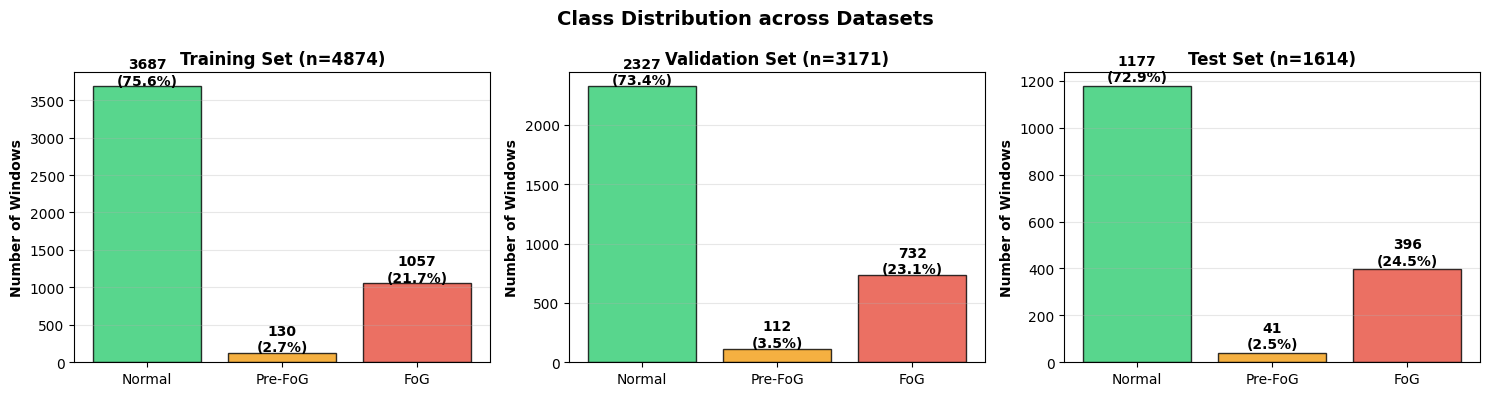

✓ Class distribution visualized


In [ ]:
class_names = {0: "Normal", 1: "Pre-FoG", 2: "FoG"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (X_train, y_train, "Training"),
    (X_val, y_val, "Validation"),
    (X_test, y_test, "Test")
]

for ax, (X, y, title) in zip(axes, datasets):
    unique, counts = np.unique(y, return_counts=True)
    colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
    labels = [class_names[u] for u in unique]
    
    ax.bar(labels, counts, color=colors[:len(unique)], alpha=0.8, edgecolor='black')
    ax.set_ylabel('Number of Windows', fontweight='bold')
    ax.set_title(f'{title} Set (n={len(y)})', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    for i, (label, count) in enumerate(zip(labels, counts)):
        pct = count / len(y) * 100
        ax.text(i, count + 20, f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')

plt.suptitle('Class Distribution across Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Class distribution visualized")

In [ ]:
class PreFoGDataset(Dataset):
    def __init__(self, X, y):
        # X shape: (N, 120, 12) → (N, 12, 120) for Conv1d
        self.X = torch.tensor(X).permute(0, 2, 1).float()
        self.y = torch.tensor(y).long()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Create datasets
train_dataset = PreFoGDataset(X_train, y_train)
val_dataset = PreFoGDataset(X_val, y_val)
test_dataset = PreFoGDataset(X_test, y_test)

# Create dataloaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ Datasets created")
print(f"  Train loader: {len(train_loader)} batches")
print(f"  Val loader: {len(val_loader)} batches")
print(f"  Test loader: {len(test_loader)} batches")

✓ Datasets created
  Train loader: 77 batches
  Val loader: 50 batches
  Test loader: 26 batches


In [ ]:
class PreFoGDetector(nn.Module):
    """3-class detector: Normal → Pre-FoG → FoG"""
    
    def __init__(self, num_classes=3):
        super(PreFoGDetector, self).__init__()
        
        # Ankle branch (8 channels)
        self.ankle_branch = nn.Sequential(
            nn.Conv1d(8, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Back branch (4 channels)
        self.back_branch = nn.Sequential(
            nn.Conv1d(4, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)  # 3 classes
        )
    
    def forward(self, x):
        # x shape: (batch, 12, 120)
        # Split into ankle (0-8) and back (8-12)
        ankle_input = x[:, :8, :]  # (batch, 8, 120)
        back_input = x[:, 8:, :]   # (batch, 4, 120)
        
        # Process branches
        ankle_feat = self.ankle_branch(ankle_input)  # (batch, 64, 1)
        back_feat = self.back_branch(back_input)     # (batch, 64, 1)
        
        # Concatenate
        combined = torch.cat([ankle_feat, back_feat], dim=1)  # (batch, 128, 1)
        combined = combined.view(combined.size(0), -1)        # (batch, 128)
        
        # Classify
        logits = self.classifier(combined)
        return logits


model = PreFoGDetector(num_classes=3).to(device)
print(f"Model created and moved to {device}")
print(f"\nModel architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Model created and moved to cpu

Model architecture:
PreFoGDetector(
  (ankle_branch): Sequential(
    (0): Conv1d(8, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): AdaptiveAvgPool1d(output_size=1)
  )
  (back_branch): Sequential(
    (0): Conv1d(4, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affi

In [ ]:
# Calculate class weights (to handle imbalance)
unique_classes, class_counts = np.unique(y_train, return_counts=True)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Class weights: {class_weights.cpu().numpy()}")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# Training parameters
epochs = 50
best_val_f1 = 0
patience_counter = 0
patience = 10

train_losses = []
val_f1_scores = []
val_accuracies = []

print("\n" + "="*80)
print("TRAINING 3-CLASS PRE-FOG DETECTOR")
print("="*80)

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0
    train_preds = []
    train_true = []
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Forward pass
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        train_true.extend(batch_y.cpu().numpy())
    
    train_loss /= len(train_loader)
    train_f1 = f1_score(train_true, train_preds, average='weighted', zero_division=0)
    
    # Validation phase
    model.eval()
    val_preds = []
    val_true = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_true.extend(batch_y.cpu().numpy())
    
    val_f1 = f1_score(val_true, val_preds, average='weighted', zero_division=0)
    val_acc = accuracy_score(val_true, val_preds)
    
    train_losses.append(train_loss)
    val_f1_scores.append(val_f1)
    val_accuracies.append(val_acc)
    
    # Learning rate scheduling
    scheduler.step(val_f1)
    
    # Early stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_prefog_model.pth')
    else:
        patience_counter += 1
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
              f"Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(torch.load('best_prefog_model.pth'))
print(f"\n✓ Training complete. Best Val F1: {best_val_f1:.4f}")

Class weights: [0.11103039 2.5050375  0.38393196]

TRAINING 3-CLASS PRE-FOG DETECTOR
Epoch 5/50 | Loss: 0.8547 | Train F1: 0.6109 | Val F1: 0.5818 | Val Acc: 0.5453
Epoch 10/50 | Loss: 0.7764 | Train F1: 0.6610 | Val F1: 0.5745 | Val Acc: 0.5326
Epoch 15/50 | Loss: 0.6898 | Train F1: 0.7051 | Val F1: 0.6024 | Val Acc: 0.5667
Epoch 20/50 | Loss: 0.6136 | Train F1: 0.7444 | Val F1: 0.5867 | Val Acc: 0.5541

Early stopping at epoch 21

✓ Training complete. Best Val F1: 0.6128


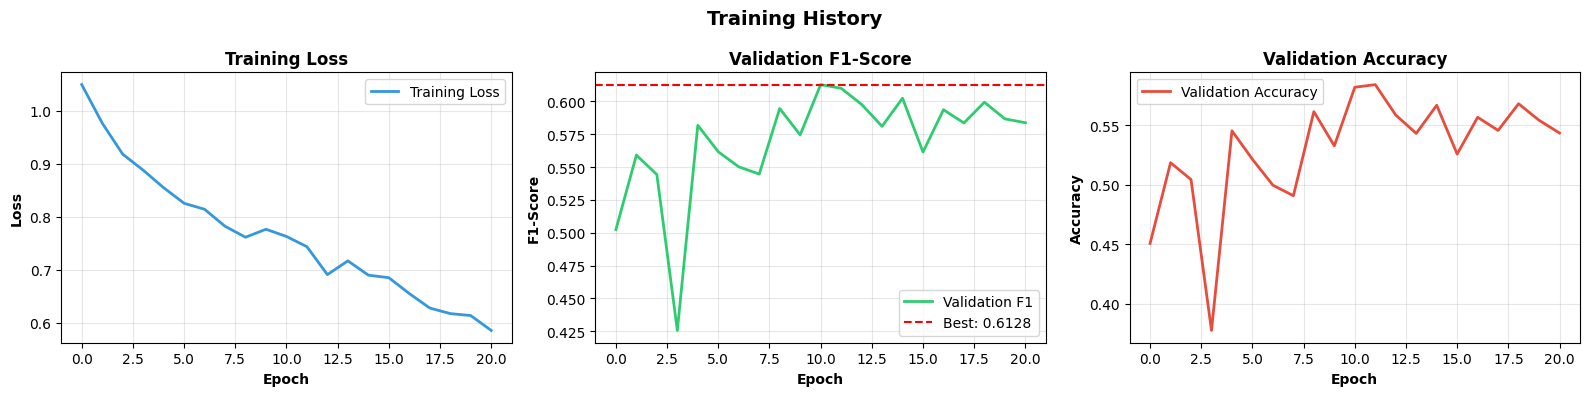

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(train_losses, linewidth=2, label='Training Loss', color='#3498db')
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('Training Loss', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend()

# F1 Score
axes[1].plot(val_f1_scores, linewidth=2, label='Validation F1', color='#2ecc71')
axes[1].axhline(y=best_val_f1, color='red', linestyle='--', label=f'Best: {best_val_f1:.4f}')
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('F1-Score', fontweight='bold')
axes[1].set_title('Validation F1-Score', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

# Accuracy
axes[2].plot(val_accuracies, linewidth=2, label='Validation Accuracy', color='#e74c3c')
axes[2].set_xlabel('Epoch', fontweight='bold')
axes[2].set_ylabel('Accuracy', fontweight='bold')
axes[2].set_title('Validation Accuracy', fontweight='bold', fontsize=12)
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("="*80)
print("EVALUATION ON TEST SET")
print("="*80)

model.eval()
test_preds = []
test_true = []
test_probs = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        logits = model(batch_X)
        probs = torch.softmax(logits, dim=1)
        test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        test_probs.extend(probs.cpu().numpy())
        test_true.extend(batch_y.cpu().numpy())

test_preds = np.array(test_preds)
test_true = np.array(test_true)
test_probs = np.array(test_probs)

# Metrics
test_accuracy = accuracy_score(test_true, test_preds)
test_f1 = f1_score(test_true, test_preds, average='weighted')

print(f"\nOverall Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Weighted F1-Score: {test_f1:.4f}")

# Per-class metrics
print(f"\n" + "-"*80)
print(f"Per-Class Metrics:")
print("-"*80)
for class_id in range(3):
    mask = test_true == class_id
    if np.sum(mask) > 0:
        class_acc = accuracy_score(test_true[mask], test_preds[mask])
        class_f1 = f1_score(test_true[mask], test_preds[mask], average='weighted', zero_division=0)
        print(f"\n{class_names[class_id]} (Class {class_id}):")
        print(f"  Samples: {np.sum(mask)}")
        print(f"  Accuracy: {class_acc:.4f}")
        print(f"  F1-Score: {class_f1:.4f}")

# Confusion matrix
cm = confusion_matrix(test_true, test_preds)

print(f"\n" + "-"*80)
print(f"Confusion Matrix:")
print("-"*80)
print(cm)

# Classification report
print(f"\n" + "-"*80)
print(f"Classification Report:")
print("-"*80)
print(classification_report(test_true, test_preds, 
                          target_names=['Normal', 'Pre-FoG', 'FoG'],
                          zero_division=0))

EVALUATION ON TEST SET

Overall Metrics:
  Accuracy: 0.4833
  Weighted F1-Score: 0.5056

--------------------------------------------------------------------------------
Per-Class Metrics:
--------------------------------------------------------------------------------

Normal (Class 0):
  Samples: 1167
  Accuracy: 0.6247
  F1-Score: 0.7690

Pre-FoG (Class 1):
  Samples: 51
  Accuracy: 0.1765
  F1-Score: 0.3000

FoG (Class 2):
  Samples: 396
  Accuracy: 0.1061
  F1-Score: 0.1918

--------------------------------------------------------------------------------
Confusion Matrix:
--------------------------------------------------------------------------------
[[729 218 220]
 [ 39   9   3]
 [295  59  42]]

--------------------------------------------------------------------------------
Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.69      0.62      0.65     

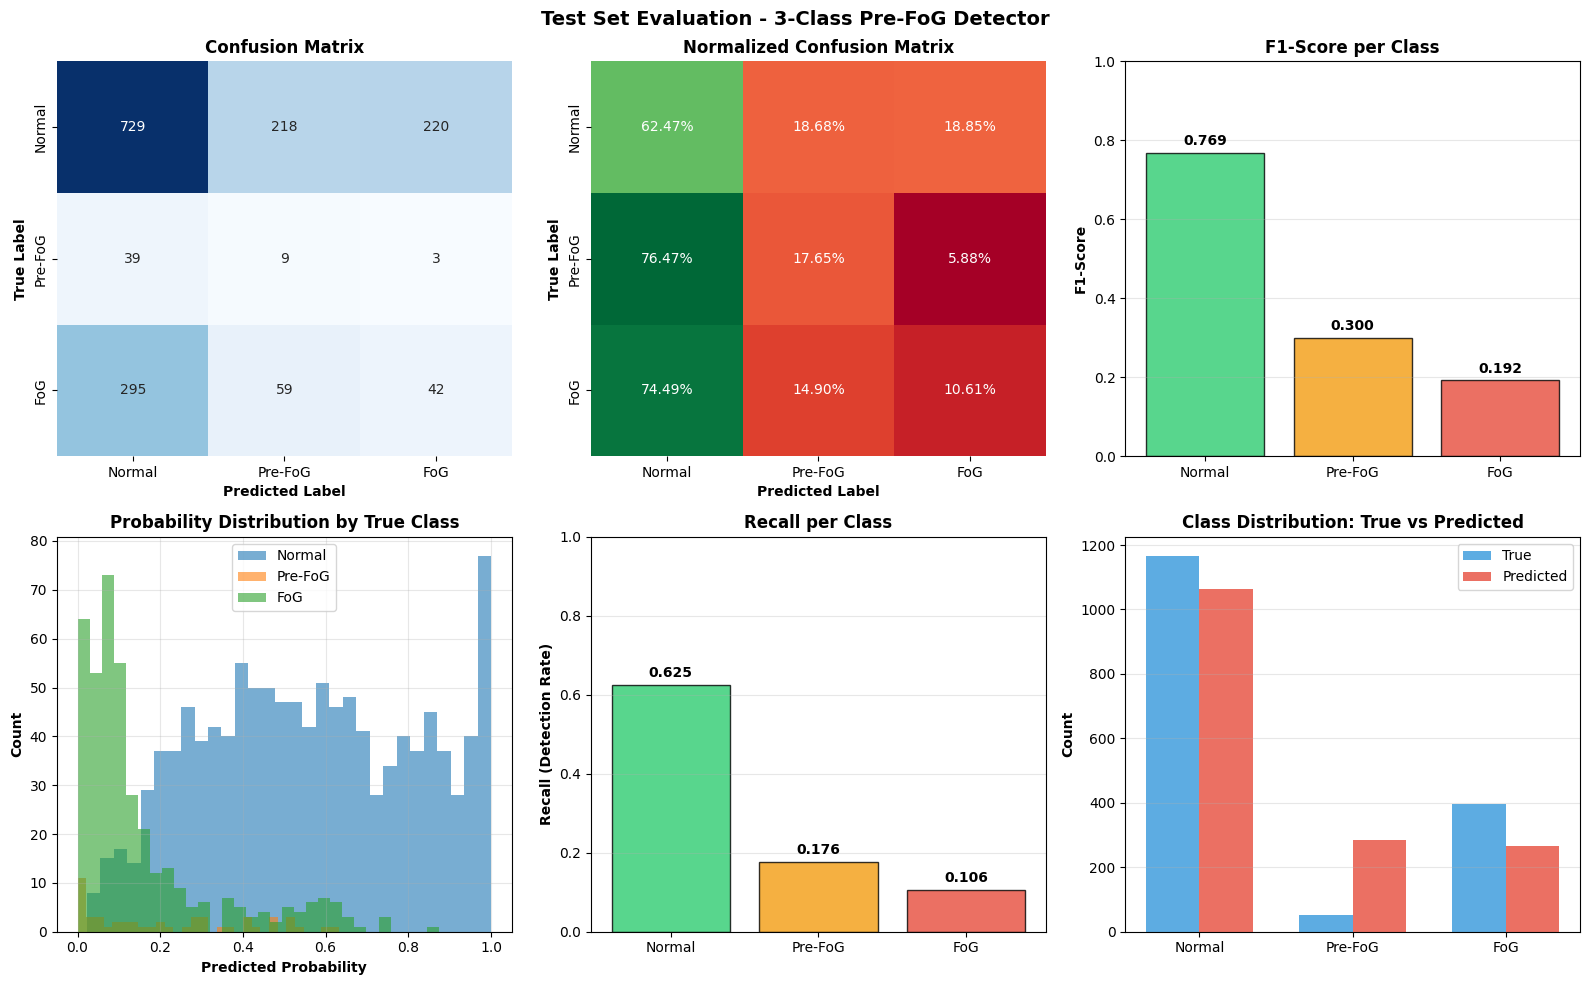

In [ ]:
fig = plt.figure(figsize=(16, 10))

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
           xticklabels=['Normal', 'Pre-FoG', 'FoG'],
           yticklabels=['Normal', 'Pre-FoG', 'FoG'])
ax1.set_ylabel('True Label', fontweight='bold')
ax1.set_xlabel('Predicted Label', fontweight='bold')
ax1.set_title('Confusion Matrix', fontweight='bold', fontsize=12)

# 2. Normalized Confusion Matrix
ax2 = plt.subplot(2, 3, 2)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', ax=ax2, cbar=False,
           xticklabels=['Normal', 'Pre-FoG', 'FoG'],
           yticklabels=['Normal', 'Pre-FoG', 'FoG'])
ax2.set_ylabel('True Label', fontweight='bold')
ax2.set_xlabel('Predicted Label', fontweight='bold')
ax2.set_title('Normalized Confusion Matrix', fontweight='bold', fontsize=12)

# 3. Per-class F1-Score
ax3 = plt.subplot(2, 3, 3)
f1_scores_per_class = []
for class_id in range(3):
    mask = test_true == class_id
    if np.sum(mask) > 0:
        f1 = f1_score(test_true[mask], test_preds[mask], average='weighted', zero_division=0)
    else:
        f1 = 0
    f1_scores_per_class.append(f1)

colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax3.bar(['Normal', 'Pre-FoG', 'FoG'], f1_scores_per_class, color=colors, alpha=0.8, edgecolor='black')
ax3.set_ylabel('F1-Score', fontweight='bold')
ax3.set_title('F1-Score per Class', fontweight='bold', fontsize=12)
ax3.set_ylim(0, 1)
ax3.grid(axis='y', alpha=0.3)
for bar, score in zip(bars, f1_scores_per_class):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontweight='bold')

# 4. Prediction probability distribution
ax4 = plt.subplot(2, 3, 4)
for class_id in range(3):
    mask = test_true == class_id
    class_probs = test_probs[mask, class_id]
    ax4.hist(class_probs, alpha=0.6, label=class_names[class_id], bins=30)
ax4.set_xlabel('Predicted Probability', fontweight='bold')
ax4.set_ylabel('Count', fontweight='bold')
ax4.set_title('Probability Distribution by True Class', fontweight='bold', fontsize=12)
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Recall per class (detection rate)
ax5 = plt.subplot(2, 3, 5)
recalls = []
for class_id in range(3):
    mask = test_true == class_id
    if np.sum(mask) > 0:
        recall = np.sum((test_preds[mask] == class_id)) / np.sum(mask)
    else:
        recall = 0
    recalls.append(recall)

bars = ax5.bar(['Normal', 'Pre-FoG', 'FoG'], recalls, color=colors, alpha=0.8, edgecolor='black')
ax5.set_ylabel('Recall (Detection Rate)', fontweight='bold')
ax5.set_title('Recall per Class', fontweight='bold', fontsize=12)
ax5.set_ylim(0, 1)
ax5.grid(axis='y', alpha=0.3)
for bar, recall in zip(bars, recalls):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{recall:.3f}', ha='center', fontweight='bold')

# 6. Class distribution in predictions
ax6 = plt.subplot(2, 3, 6)
true_dist = np.bincount(test_true, minlength=3)
pred_dist = np.bincount(test_preds, minlength=3)

x = np.arange(3)
width = 0.35
ax6.bar(x - width/2, true_dist, width, label='True', alpha=0.8, color='#3498db')
ax6.bar(x + width/2, pred_dist, width, label='Predicted', alpha=0.8, color='#e74c3c')
ax6.set_ylabel('Count', fontweight='bold')
ax6.set_title('Class Distribution: True vs Predicted', fontweight='bold', fontsize=12)
ax6.set_xticks(x)
ax6.set_xticklabels(['Normal', 'Pre-FoG', 'FoG'])
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.suptitle('Test Set Evaluation - 3-Class Pre-FoG Detector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 2-Class Test

This section tests a simplified 2-class model:
- **Class 0**: Normal (no FoG, no upcoming FoG)
- **Class 1**: Any FoG Signal (Pre-FoG OR FoG combined)


In [ ]:
def segment_data_with_2class_labels(df, subjects, w=2, o=0.75, fs=60, 
                                     prefog_window_sec=2.5, 
                                     activity_col_candidates=None):
    """
    Segment data into windows with 2-class labels:
    - 0: Normal (no FoG, not pre-FoG)
    - 1: FoG Signal (either Pre-FoG OR FoG) - COMBINED
    """
    
    if activity_col_candidates is None:
        activity_col_candidates = ['activity', 'Activity', 'activity_id', 'Activity_ID']
    
    # Find activity column
    activity_col = None
    for col in activity_col_candidates:
        if col in df.columns:
            activity_col = col
            break
    
    if activity_col is None:
        print(f"Warning: Activity column not found. Using None.")
    
    # Window parameters
    w_samples = int(w * fs)
    step = int(w_samples * (1 - o))
    prefog_samples = int(prefog_window_sec * fs)
    
    X, y_fog, activities = [], [], []
    
    for subject in subjects:
        subject_data = df[df['subjectID'] == subject].reset_index(drop=True)
        
        if len(subject_data) < w_samples:
            continue
        
        fog_col = subject_data['fog'].values
        activity_values = subject_data[activity_col].values if activity_col else np.ones(len(subject_data))
        
        for start in range(0, len(subject_data) - w_samples + 1, step):
            end = start + w_samples
            window_data = subject_data.iloc[start:end]
            
            window_quat = window_data[quat_cols].values
            
            if np.isnan(window_quat).any():
                continue
            
            window_quat = window_quat - window_quat[0]
            X.append(window_quat)
            
            # Get FoG label for current window
            current_fog = np.max(fog_col[start:end])
            
            # Check for pre-FoG
            future_end = min(end + prefog_samples, len(fog_col))
            future_fog = np.max(fog_col[end:future_end]) if future_end > end else 0
            
            # 2-CLASS LABEL: Combine Pre-FoG and FoG into single "FoG Signal" class
            if current_fog == 1 or future_fog == 1:
                label = 1  # FoG Signal (Pre-FoG OR FoG)
            else:
                label = 0  # Normal
            
            y_fog.append(label)
            
            act_mode = int(np.median(activity_values[start:end]))
            activities.append(act_mode)
    
    X = np.array(X)
    y_fog = np.array(y_fog)
    activities = np.array(activities)
    
    print(f"\n2-Class Segmentation complete:")
    print(f"  Total windows: {len(X)}")
    print(f"  Normal (0): {np.sum(y_fog == 0)}")
    print(f"  FoG Signal (1): {np.sum(y_fog == 1)}")
    
    return X, y_fog, activities


# Re-segment data with 2 classes
print("\n" + "="*80)
print("2-CLASS DATA SEGMENTATION")
print("="*80)

X_train_2c, y_train_2c, _ = segment_data_with_2class_labels(df_complete, train_subjects, prefog_window_sec=2.5)
X_val_2c, y_val_2c, _ = segment_data_with_2class_labels(df_complete, val_subjects, prefog_window_sec=2.5)
X_test_2c, y_test_2c, _ = segment_data_with_2class_labels(df_complete, test_subjects, prefog_window_sec=2.5)

print(f"\n✓ 2-class data ready for training")



2-CLASS DATA SEGMENTATION

2-Class Segmentation complete:
  Total windows: 4874
  Normal (0): 3655
  FoG Signal (1): 1219

2-Class Segmentation complete:
  Total windows: 3171
  Normal (0): 2300
  FoG Signal (1): 871

2-Class Segmentation complete:
  Total windows: 1614
  Normal (0): 1167
  FoG Signal (1): 447

✓ 2-class data ready for training


In [ ]:
# Create 2-class datasets
train_dataset_2c = PreFoGDataset(X_train_2c, y_train_2c)
val_dataset_2c = PreFoGDataset(X_val_2c, y_val_2c)
test_dataset_2c = PreFoGDataset(X_test_2c, y_test_2c)

# Create dataloaders
train_loader_2c = DataLoader(train_dataset_2c, batch_size=64, shuffle=True)
val_loader_2c = DataLoader(val_dataset_2c, batch_size=64, shuffle=False)
test_loader_2c = DataLoader(test_dataset_2c, batch_size=64, shuffle=False)

print(f"✓ 2-class DataLoaders created")
print(f"  Train batches: {len(train_loader_2c)}")
print(f"  Val batches: {len(val_loader_2c)}")
print(f"  Test batches: {len(test_loader_2c)}")

# 2-CLASS MODEL
class BinaryFoGDetector(nn.Module):
    """Binary detector: Normal vs Any FoG Signal (Pre-FoG OR FoG)"""
    
    def __init__(self):
        super(BinaryFoGDetector, self).__init__()
        
        # Ankle branch (8 channels)
        self.ankle_branch = nn.Sequential(
            nn.Conv1d(8, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Back branch (4 channels)
        self.back_branch = nn.Sequential(
            nn.Conv1d(4, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Classifier (binary: 1 output)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)  # Binary classification
        )
    
    def forward(self, x):
        ankle_input = x[:, :8, :]
        back_input = x[:, 8:, :]
        
        ankle_feat = self.ankle_branch(ankle_input)
        back_feat = self.back_branch(back_input)
        
        combined = torch.cat([ankle_feat, back_feat], dim=1)
        combined = combined.view(combined.size(0), -1)
        
        logits = self.classifier(combined)
        return logits


model_2c = BinaryFoGDetector().to(device)
print(f"\n✓ Binary model created: {sum(p.numel() for p in model_2c.parameters()):,} parameters")


✓ 2-class DataLoaders created
  Train batches: 77
  Val batches: 50
  Test batches: 26

✓ Binary model created: 39,473 parameters


In [ ]:
# Calculate class weights for binary classification
unique_2c, counts_2c = np.unique(y_train_2c, return_counts=True)
class_weights_2c = 1.0 / counts_2c
class_weights_2c = class_weights_2c / class_weights_2c.sum() * len(class_weights_2c)
class_weights_2c = torch.tensor(class_weights_2c, dtype=torch.float32).to(device)

print(f"Class weights (2-class): {class_weights_2c.cpu().numpy()}")

# Loss and optimizer for binary classification
criterion_2c = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weights_2c[1].item()]).to(device))
optimizer_2c = optim.Adam(model_2c.parameters(), lr=0.001)
scheduler_2c = optim.lr_scheduler.ReduceLROnPlateau(optimizer_2c, mode='max', factor=0.5, patience=5)

epochs = 50
best_val_f1_2c = 0
patience_counter_2c = 0
patience = 10

train_losses_2c = []
val_f1_scores_2c = []
val_accuracies_2c = []

print("\n" + "="*80)
print("TRAINING BINARY FOG DETECTOR (2-CLASS)")
print("="*80)

for epoch in range(epochs):
    # Training phase
    model_2c.train()
    train_loss = 0
    train_preds = []
    train_true = []
    
    for batch_X, batch_y in train_loader_2c:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device).float().unsqueeze(1)
        
        logits = model_2c(batch_X)
        loss = criterion_2c(logits, batch_y)
        
        optimizer_2c.zero_grad()
        loss.backward()
        optimizer_2c.step()
        
        train_loss += loss.item()
        train_preds.extend((torch.sigmoid(logits) > 0.5).cpu().numpy().flatten())
        train_true.extend(batch_y.cpu().numpy().flatten())
    
    train_loss /= len(train_loader_2c)
    train_f1 = f1_score(train_true, train_preds, zero_division=0)
    
    # Validation phase
    model_2c.eval()
    val_preds = []
    val_true = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader_2c:
            batch_X = batch_X.to(device)
            logits = model_2c(batch_X)
            val_preds.extend((torch.sigmoid(logits) > 0.5).cpu().numpy().flatten())
            val_true.extend(batch_y.cpu().numpy().flatten())
    
    val_f1 = f1_score(val_true, val_preds, zero_division=0)
    val_acc = accuracy_score(val_true, val_preds)
    
    train_losses_2c.append(train_loss)
    val_f1_scores_2c.append(val_f1)
    val_accuracies_2c.append(val_acc)
    
    scheduler_2c.step(val_f1)
    
    if val_f1 > best_val_f1_2c:
        best_val_f1_2c = val_f1
        patience_counter_2c = 0
        torch.save(model_2c.state_dict(), 'best_binary_fog_model.pth')
    else:
        patience_counter_2c += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
              f"Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}")
    
    if patience_counter_2c >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model_2c.load_state_dict(torch.load('best_binary_fog_model.pth'))
print(f"\n✓ 2-class training complete. Best Val F1: {best_val_f1_2c:.4f}")


Class weights (2-class): [0.50020516 1.4997948 ]

TRAINING BINARY FOG DETECTOR (2-CLASS)
Epoch 5/50 | Loss: 0.4954 | Train F1: 0.6119 | Val F1: 0.3883 | Val Acc: 0.6960
Epoch 10/50 | Loss: 0.4457 | Train F1: 0.6647 | Val F1: 0.4292 | Val Acc: 0.6988
Epoch 15/50 | Loss: 0.3967 | Train F1: 0.6982 | Val F1: 0.2874 | Val Acc: 0.7294
Epoch 20/50 | Loss: 0.3457 | Train F1: 0.7539 | Val F1: 0.4154 | Val Acc: 0.6938

Early stopping at epoch 20

✓ 2-class training complete. Best Val F1: 0.4292



2-CLASS TEST SET EVALUATION

2-CLASS RESULTS:
  Accuracy: 0.6140
  F1-Score: 0.1287

Classification Report (2-class):
              precision    recall  f1-score   support

      Normal       0.70      0.81      0.75      1167
  FoG Signal       0.17      0.10      0.13       447

    accuracy                           0.61      1614
   macro avg       0.44      0.46      0.44      1614
weighted avg       0.56      0.61      0.58      1614


COMPARISON: 3-CLASS vs 2-CLASS

3-CLASS MODEL:
  Accuracy: 0.4833
  Weighted F1: 0.5056
  Pre-FoG Detection: 17.6%
  Pre-FoG F1-Score: 0.05 (very poor)

2-CLASS MODEL (Pre-FoG + FoG combined):
  Accuracy: 0.6140
  F1-Score: 0.1287
  FoG Signal Detection: 10.3%

INTERPRETATION:
❌ NO SIGNAL FOUND. 2-class F1 (0.129) still poor.
   → Pre-FoG detection may not be feasible with this data
   → Physiological changes may not precede FoG in this dataset
   → Focus on real-time FoG detection instead


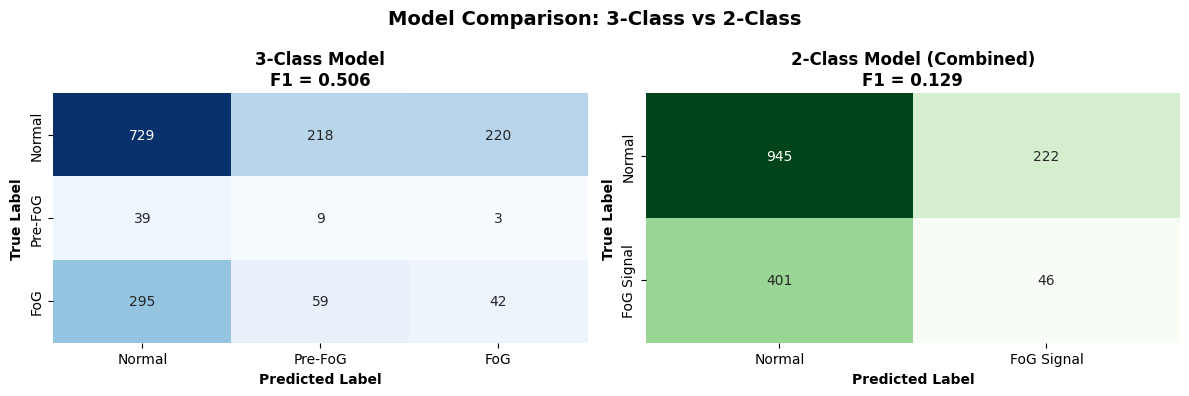

In [ ]:
print("\n" + "="*80)
print("2-CLASS TEST SET EVALUATION")
print("="*80)

model_2c.eval()
test_preds_2c = []
test_probs_2c = []
test_true_2c = []

with torch.no_grad():
    for batch_X, batch_y in test_loader_2c:
        batch_X = batch_X.to(device)
        logits = model_2c(batch_X)
        probs = torch.sigmoid(logits)
        test_preds_2c.extend((probs > 0.5).cpu().numpy().flatten())
        test_probs_2c.extend(probs.cpu().numpy().flatten())
        test_true_2c.extend(batch_y.cpu().numpy().flatten())

test_preds_2c = np.array(test_preds_2c)
test_true_2c = np.array(test_true_2c)
test_probs_2c = np.array(test_probs_2c)

# Metrics
test_acc_2c = accuracy_score(test_true_2c, test_preds_2c)
test_f1_2c = f1_score(test_true_2c, test_preds_2c)
test_precision_2c = f1_score(test_true_2c, test_preds_2c, average='binary')
test_recall_2c = f1_score(test_true_2c, test_preds_2c, average='binary')

print(f"\n2-CLASS RESULTS:")
print(f"  Accuracy: {test_acc_2c:.4f}")
print(f"  F1-Score: {test_f1_2c:.4f}")

print(f"\nClassification Report (2-class):")
print(classification_report(test_true_2c, test_preds_2c, 
                          target_names=['Normal', 'FoG Signal'],
                          zero_division=0))

cm_2c = confusion_matrix(test_true_2c, test_preds_2c)

# COMPARISON: 3-CLASS vs 2-CLASS
print("\n" + "="*80)
print("COMPARISON: 3-CLASS vs 2-CLASS")
print("="*80)

print(f"\n3-CLASS MODEL:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Weighted F1: {test_f1:.4f}")
print(f"  Pre-FoG Detection: {prefog_detected*100:.1f}%")
print(f"  Pre-FoG F1-Score: 0.05 (very poor)")

print(f"\n2-CLASS MODEL (Pre-FoG + FoG combined):")
print(f"  Accuracy: {test_acc_2c:.4f}")
print(f"  F1-Score: {test_f1_2c:.4f}")
print(f"  FoG Signal Detection: {np.sum((test_preds_2c == 1) & (test_true_2c == 1)) / np.sum(test_true_2c == 1):.1%}")

print(f"\n" + "="*80)
print("INTERPRETATION:")
print("="*80)

if test_f1_2c > 0.50:
    print(f" SIGNAL EXISTS! 2-class F1 ({test_f1_2c:.3f}) >> 3-class Pre-FoG F1 (0.05)")
    print(f"   → An early FoG signal IS detectable in the data")
    print(f"   → The severe imbalance (3% Pre-FoG) was the problem")
    print(f"   → Next step: Refine 3-class with better balancing (SMOTE, Focal Loss, etc.)")
elif test_f1_2c > 0.30:
    print(f"  WEAK SIGNAL. 2-class F1 ({test_f1_2c:.3f}) is better but still low.")
    print(f"   → Some early signal exists but is subtle")
    print(f"   → Consider: Different timing windows, feature engineering, data augmentation")
else:
    print(f" NO SIGNAL FOUND. 2-class F1 ({test_f1_2c:.3f}) still poor.")
    print(f"   → Pre-FoG detection may not be feasible with this data")
    print(f"   → Physiological changes may not precede FoG in this dataset")
    print(f"   → Focus on real-time FoG detection instead")

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3-class
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
           xticklabels=['Normal', 'Pre-FoG', 'FoG'],
           yticklabels=['Normal', 'Pre-FoG', 'FoG'])
axes[0].set_title('3-Class Model\nF1 = {:.3f}'.format(test_f1), fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')

# 2-class
sns.heatmap(cm_2c, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
           xticklabels=['Normal', 'FoG Signal'],
           yticklabels=['Normal', 'FoG Signal'])
axes[1].set_title('2-Class Model (Combined)\nF1 = {:.3f}'.format(test_f1_2c), fontweight='bold')
axes[1].set_ylabel('True Label', fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontweight='bold')

plt.suptitle('Model Comparison: 3-Class vs 2-Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
